# Riskfolio-Lib Tutorial: 
<br><a href="https://www.kqzyfj.com/click-101360347-15150084?url=https%3A%2F%2Flink.springer.com%2Fbook%2F9783031843037" target="_blank">
<div>
<img src="https://raw.githubusercontent.com/dcajasn/Riskfolio-Lib/refs/heads/master/docs/source/_static/Button.png" height="40" />
</div>
<br>
</a>
<a href="https://www.paypal.com/ncp/payment/GN55W4UQ7VAMN" target="_blank">
<div>
<img src="https://raw.githubusercontent.com/dcajasn/Riskfolio-Lib/refs/heads/master/docs/source/_static/Button2.png" height="40" />
</div>
</a>

<br><a href='https://ko-fi.com/B0B833SXD' target='_blank'><img height='36' style='border:0px;height:36px;' src='https://cdn.ko-fi.com/cdn/kofi1.png?v=2' border='0' alt='Buy Me a Coffee at ko-fi.com' /></a> 
<br>
<br>__[Financionerioncios](https://financioneroncios.wordpress.com)__
<br>__[Orenji](https://www.linkedin.com/company/orenj-i)__
<br>__[Riskfolio-Lib](https://riskfolio-lib.readthedocs.io/en/latest/)__
<br>__[Dany Cajas](https://www.linkedin.com/in/dany-cajas/)__
## Tutorial 58: Mean Variance Skewness Kurtosis Optimization

## 1. Downloading the data:

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import warnings

warnings.filterwarnings("ignore")
pd.options.display.float_format = '{:.4%}'.format

# Date range
start = '2016-01-01'
end = '2019-12-30'

# Tickers of assets
assets = ['JCI', 'AMZN', 'CMCSA', 'CPB', 'MO', 'APA', 'MRSH', 'JPM',
          'ZION', 'AAPL', 'BAX', 'BMY', 'LUV', 'PCAR', 'TXT', 'TMO',
          'DE', 'MSFT', 'HPQ', 'SEE', 'VZ', 'CNP', 'NI', 'T', 'BA']
assets.sort()

# Downloading data
data = yf.download(assets, start = start, end = end, auto_adjust=False)
data = data.loc[:,('Adj Close', slice(None))]
data.columns = assets

[*********************100%***********************]  25 of 25 completed


In [2]:
# Calculating returns

Y = data[assets].pct_change().dropna()

display(Y.head())

,AAPL,AMZN,APA,BA,BAX,BMY,CMCSA,CNP,CPB,DE,...,MRSH,MSFT,NI,PCAR,SEE,T,TMO,TXT,VZ,ZION
Date,,,,,,,,,,,,,,,,,,,,,
2016-01-05,-2.5059%,-0.5024%,-2.0257%,0.4057%,0.4035%,1.9692%,0.0180%,0.9305%,0.3678%,0.5783%,...,0.8284%,0.4562%,1.5881%,0.0212%,0.9758%,0.6987%,-0.1730%,0.2410%,1.3734%,-1.0857%
2016-01-06,-1.9570%,-0.1799%,-11.4863%,-1.5879%,0.2412%,-1.7557%,-0.7727%,-1.2473%,-0.1736%,-1.1239%,...,-1.2050%,-1.8165%,0.5547%,0.0212%,-1.5646%,0.3107%,-0.7652%,-3.0048%,-0.9034%,-2.9145%
2016-01-07,-4.2204%,-3.9058%,-5.1388%,-4.1922%,-1.6573%,-2.7699%,-1.1047%,-1.9769%,-1.2207%,-0.8855%,...,-0.7577%,-3.4783%,-2.2067%,-3.0310%,-3.1557%,-1.6148%,-2.2845%,-2.0570%,-0.5492%,-3.0020%
2016-01-08,0.5287%,-0.1464%,0.2736%,-2.2705%,-1.6036%,-2.5425%,0.1099%,-0.2241%,0.5707%,-1.6402%,...,-1.3966%,0.3067%,-0.1538%,-1.1366%,-0.1448%,0.0895%,-0.1117%,-1.1387%,-0.9719%,-1.1254%
2016-01-11,1.6192%,1.7610%,-4.3383%,0.1693%,-1.6851%,-1.0215%,0.0915%,-1.1791%,0.5674%,0.5287%,...,-1.4542%,-0.0573%,1.6436%,0.0000%,-0.1450%,1.2224%,0.5367%,-0.4608%,0.5799%,-1.9918%


## 2. Estimating Mean - Variance Portfolios

### 2.1 Calculating the portfolio that optimize return/variance ratio

In [3]:
import riskfolio as rp
import mosek

# Building the portfolio object
port = rp.Portfolio(returns=Y)

# Calculating optimum portfolio

# Select method and estimate input parameters:

method_mu='hist' # Method to estimate expected returns based on historical data.
method_cov='hist' # Method to estimate covariance matrix based on historical data.
method_kurt='hist' # Method to estimate kurtosis based on historical data.

port.assets_stats(method_mu=method_mu,
                  method_cov=method_cov,
                  method_kurt=method_kurt,
                  )

# Estimate optimal portfolio:

port.solvers = ['MOSEK'] # It is recommended to use mosek when optimizing Semi Kurtosis

model ='Classic' # Could be Classic (historical), BL (Black Litterman) or FM (Factor Model)
rm = 'MV' # Risk measure used, this time will be Even Semi Moment
obj = 'Sharpe' # Objective function, could be MinRisk, MaxRet, Utility or Sharpe
hist = True # Use historical scenarios for risk measures that depend on scenarios
rf = 0 # Risk free rate
l = 0 # Risk aversion factor, only useful when obj is 'Utility'

w_1 = port.optimization(model=model, rm=rm, obj=obj, rf=rf, l=l, hist=hist)

display(w_1.T)

You must convert self.kurt to a positive definite matrix
You must convert self.skurt to a positive definite matrix


,AAPL,AMZN,APA,BA,BAX,BMY,CMCSA,CNP,CPB,DE,...,MRSH,MSFT,NI,PCAR,SEE,T,TMO,TXT,VZ,ZION
weights,11.0704%,3.5219%,0.0000%,5.6948%,10.3298%,0.0000%,0.0000%,7.6750%,0.0000%,3.1369%,...,22.9509%,9.9803%,10.2395%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,7.6374%,0.0000%


### 2.2 Plotting portfolio composition

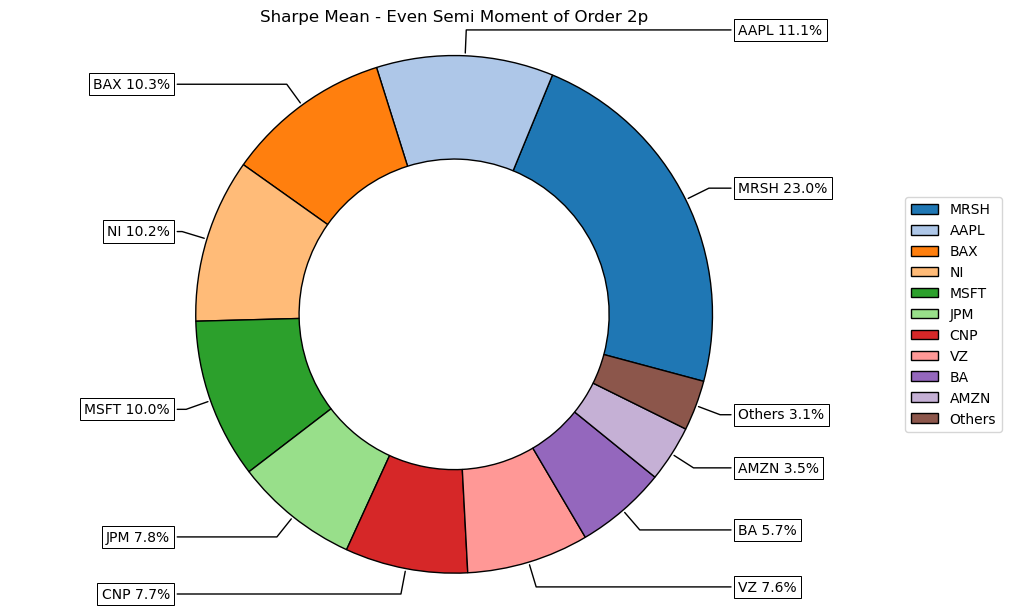

In [4]:
# Plotting the composition of the portfolio

ax = rp.plot_pie(w=w_1,
                 title='Sharpe Mean - Even Semi Moment of Order 2p',
                 others=0.05,
                 nrow=25,
                 cmap = "tab20",
                 height=6,
                 width=10,
                 ax=None)

### 2.3 Plotting risk measures

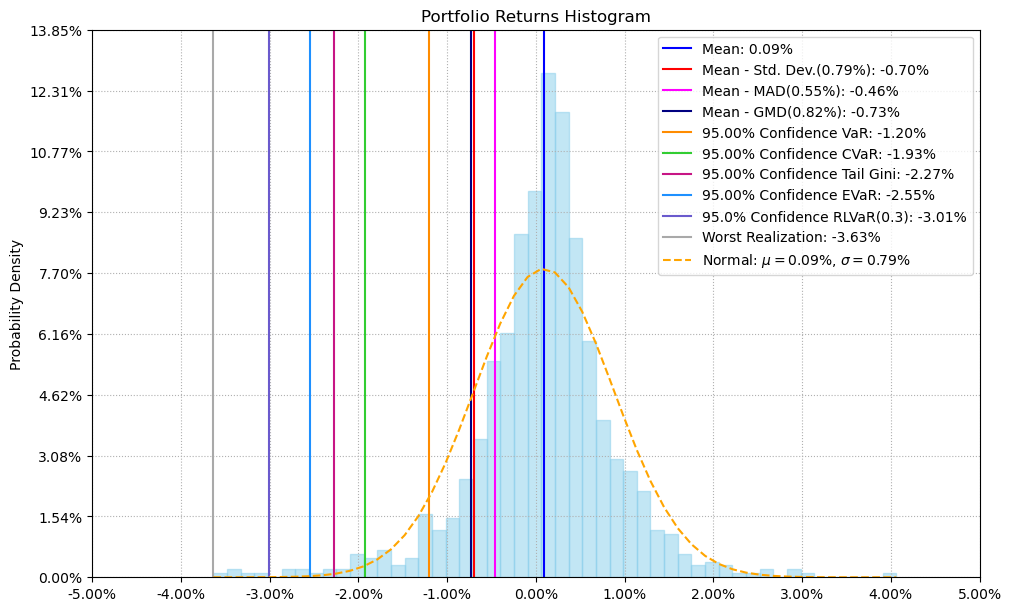

In [5]:
ax = rp.plot_hist(returns=Y,
                  w=w_1,
                  alpha=0.05,
                  bins=50,
                  height=6,
                  width=10,
                  ax=None)

### 2.4 Calculate efficient frontier

In [6]:
points = 50 # Number of points of the frontier

frontier = port.efficient_frontier(model=model, rm=rm, points=points, rf=rf, hist=hist)

display(frontier.T.head())

,AAPL,AMZN,APA,BA,BAX,BMY,CMCSA,CNP,CPB,DE,...,MRSH,MSFT,NI,PCAR,SEE,T,TMO,TXT,VZ,ZION
0,1.8851%,0.8698%,0.0000%,0.2531%,6.0107%,4.8743%,2.2911%,7.9901%,5.2223%,0.0001%,...,16.0576%,0.0000%,16.0143%,0.0000%,1.1903%,6.0423%,0.0000%,0.0014%,11.0992%,0.0003%
1,5.6039%,2.3629%,0.0000%,2.2769%,8.4056%,0.5790%,1.3841%,9.0094%,3.4498%,0.7799%,...,20.5167%,0.0000%,15.9954%,0.0000%,0.0000%,4.9353%,0.0000%,0.0000%,12.3310%,0.0000%
2,7.2706%,3.1439%,0.0000%,3.1643%,9.2539%,0.0000%,0.7389%,9.2622%,2.4494%,1.3060%,...,22.2677%,0.0000%,15.8562%,0.0000%,0.0000%,4.0536%,0.0001%,0.0000%,12.8850%,0.0000%
3,8.4881%,3.4560%,0.0000%,3.8075%,9.6459%,0.0000%,0.0009%,9.2438%,0.6722%,1.6851%,...,23.0277%,1.2866%,15.0307%,0.0000%,0.0000%,2.2350%,0.0001%,0.0000%,12.8832%,0.0000%
4,9.2516%,3.4937%,0.0000%,4.3055%,9.8230%,0.0000%,0.0000%,9.0371%,0.0000%,2.0802%,...,23.2338%,3.2253%,14.0597%,0.0000%,0.0000%,0.4559%,0.0000%,0.0000%,12.5365%,0.0000%


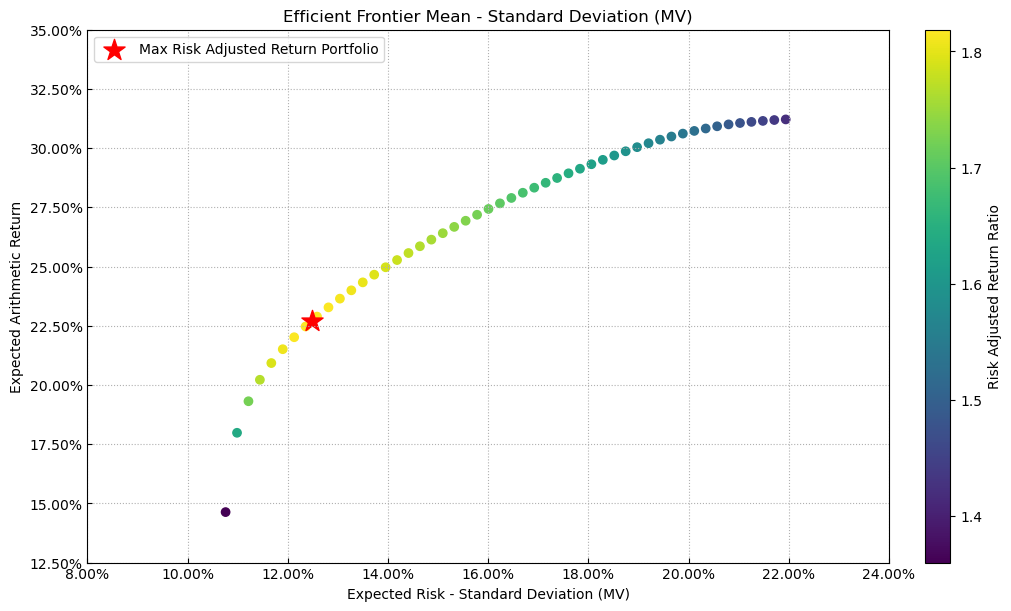

In [7]:
# Plotting the efficient frontier

label = 'Max Risk Adjusted Return Portfolio' # Title of point
mu = port.mu # Expected returns
cov = port.cov # Covariance matrix
returns = port.returns # Returns of the assets

ax = rp.plot_frontier(
    w_frontier=frontier,
    mu=mu,
    cov=cov,
    returns=returns,
    rm=rm,
    rf=rf,
    p_esm=port.p_esm,
    cmap='viridis',
    w=w_1,
    label=label,
    marker='*',
    s=16,
    c='r',
    height=6,
    width=10,
    ax=None)

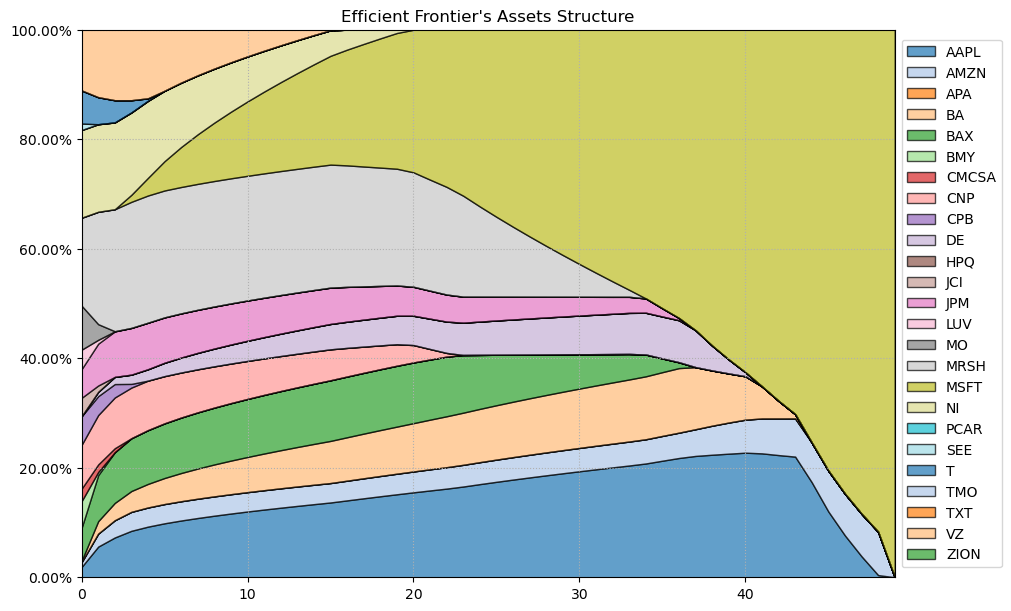

In [8]:
# Plotting efficient frontier composition

ax = rp.plot_frontier_area(w_frontier=frontier, cmap="tab20", height=6, width=10, ax=None)

## 3. Estimating Mean Variance Skewness Kurtosis Portfolios

### 3.1 Calculating the portfolio that optimize return/variance-skewness-kurtosis ratio

In [9]:
model = 'Classic' # Could be Classic (historical), FM (Factor Model) or EP (Entropy Pooling)
obj = 'Sharpe' # Objective function, could be MinRisk, MaxRet, Utility or Sharpe
rf = 0 # Risk free rate
l = [1,2,3] # Coefficients of the portfolio variance, skewness and kurtosis in the risk function
solvers = ['SCS']
w_2 = port.mvsk_optimization(model=model, obj=obj, rf=rf, l=l, solvers=solvers)

display(w_2.T)

,AAPL,AMZN,APA,BA,BAX,BMY,CMCSA,CNP,CPB,DE,...,MRSH,MSFT,NI,PCAR,SEE,T,TMO,TXT,VZ,ZION
weights,8.4974%,3.4219%,0.0000%,3.6732%,9.5501%,0.0000%,0.0000%,9.3682%,0.9143%,1.5532%,...,23.1632%,1.2048%,14.9830%,0.0000%,0.0000%,2.2078%,0.0000%,0.0000%,13.0646%,0.0000%


### 3.2 Plotting portfolio composition

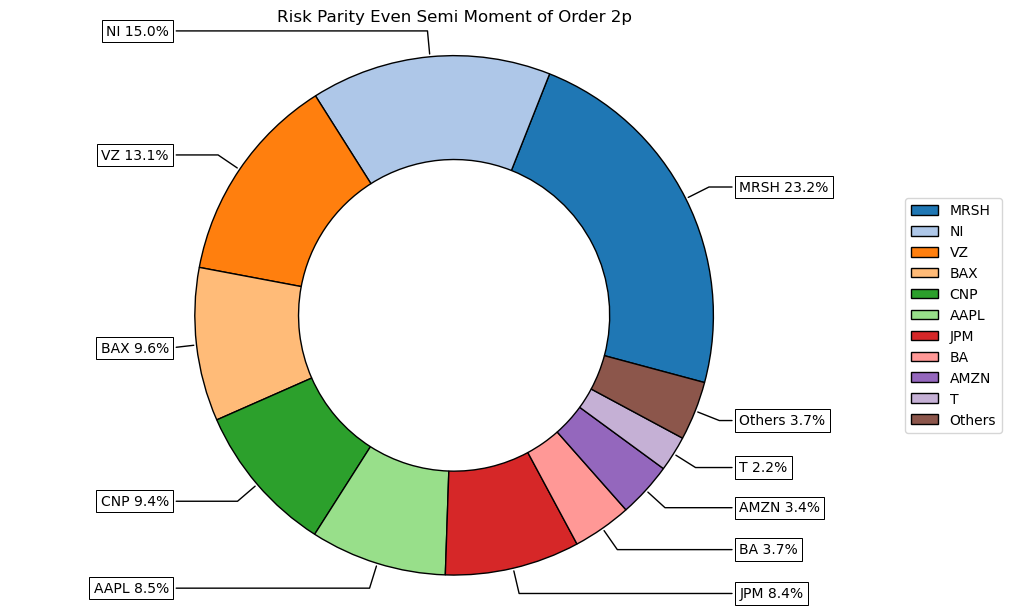

In [10]:
ax = rp.plot_pie(w=w_2,
                 title='Risk Parity Even Semi Moment of Order 2p',
                 others=0.05,
                 nrow=25,
                 cmap="tab20",
                 height=6,
                 width=10,
                 ax=None)

### 3.3 Plotting risk measures

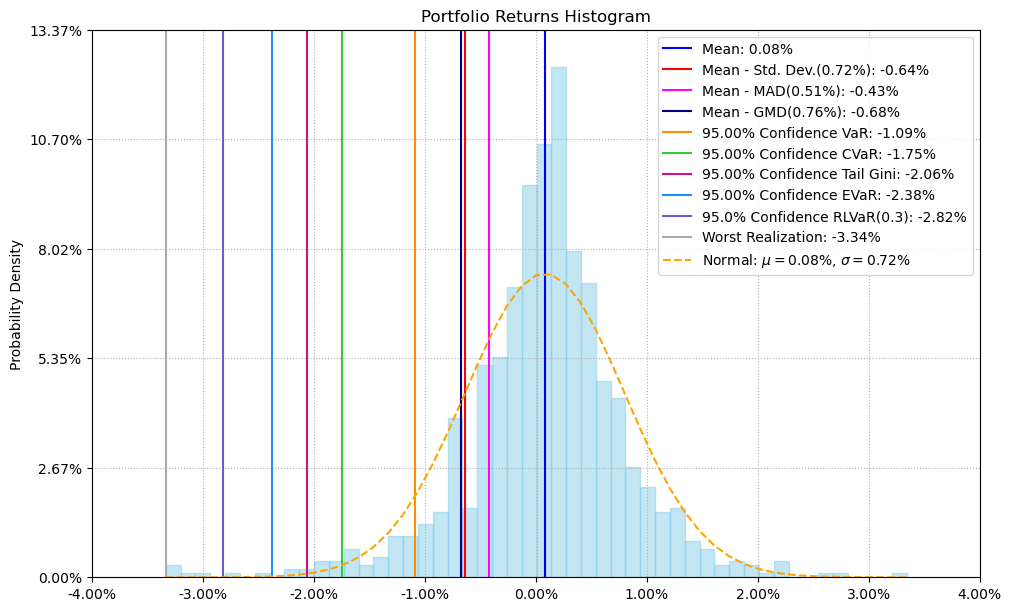

In [11]:
ax = rp.plot_hist(returns=Y,
                  w=w_2,
                  alpha=0.05,
                  bins=50,
                  height=6,
                  width=10,
                  ax=None)

### 3.4 Plotting the efficient frontier with both portfolios

In [12]:
# Combining the weights of the two portfolios in a dataframe

ws = pd.concat([w_1, w_2],axis=1)
ws.columns = ["Max Return/Variance", "Max Return/Variance-Skewness-Kurtosis"]

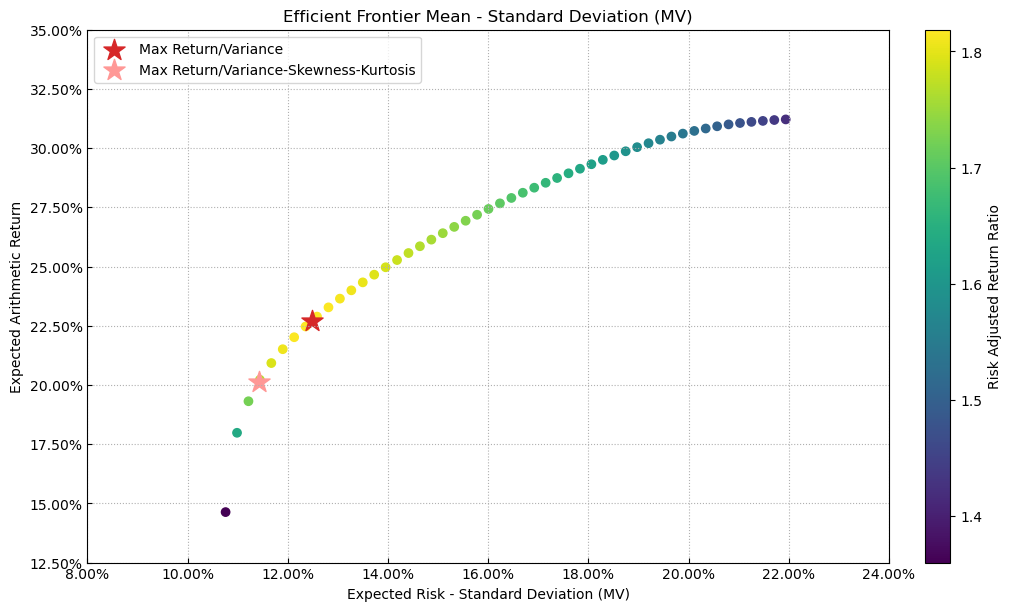

In [13]:
# Plotting the efficient frontier in Mean Standard Deviation space

mu = port.mu # Expected returns
cov = port.cov # Covariance matrix
returns = port.returns # Returns of the assets

ax = rp.plot_frontier(
    w_frontier=frontier,
    mu=mu,
    cov=cov,
    returns=returns,
    rm=rm,
    rf=rf,
    cmap='viridis',
    w=ws,
    label=label,
    marker='*',
    s=16,
    c='r',
    height=6,
    width=10,
    ax=None)


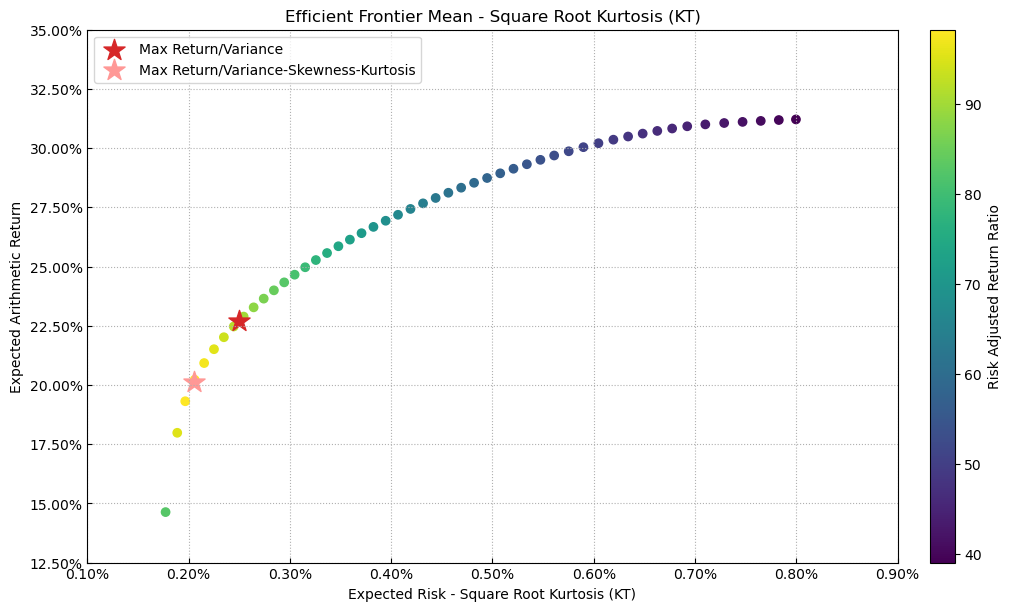

In [14]:
# Plotting the efficient frontier in Mean Square Root Kurtosis space
ax = rp.plot_frontier(
    w_frontier=frontier,
    mu=mu,
    cov=cov,
    returns=returns,
    rm='KT',
    rf=rf,
    cmap='viridis',
    w=ws,
    label=label,
    marker='*',
    s=16,
    c='r',
    height=6,
    width=10,
    ax=None)
